# Titanic Dataset EDA

In this project, I am exploring the Titanic dataset to understand the passengers and find out which factors were related to survival.

I will look at the data, handle missing values, and use different charts to understand the relationships between the variables.

In [5]:
#import titanic csv file

from google.colab import files

uploaded = files.upload()

Saving train.csv to train.csv


In [ ]:
#import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df= pd.read_csv("train.csv")

In [17]:
#Analyse
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [18]:

df.shape


(891, 12)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [20]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [21]:
#check missing value
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [26]:

(df.isnull().sum() ).sort_values(ascending=False) #sort them according decending  order

,0
Cabin,687
Age,177
Embarked,2
PassengerId,0
Name,0
Pclass,0
Survived,0
Sex,0
Parch,0
SibSp,0


In [36]:
# fill in vacant value



df["Age"] = df["Age"].fillna(df["Age"].median())

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

print(df["Age"])
print(df["Embarked"])




0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    28.0
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64
0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: object


In [58]:
#now check any duplicate
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [37]:
#now check null value
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [42]:
#count servive
df["Survived"].value_counts()

,count
Survived,
0,549
1,342


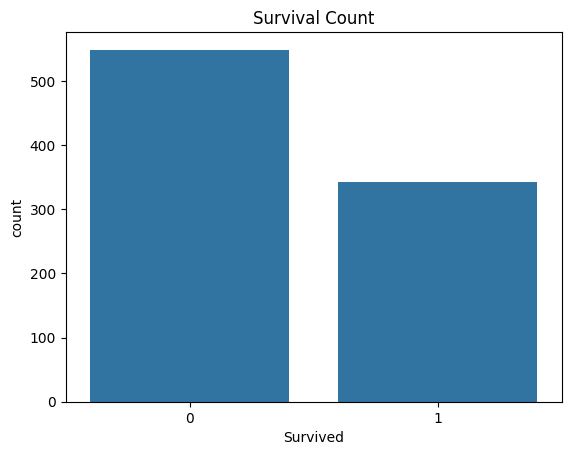

In [43]:
#compare servived & dead
sns.countplot(data=df, x="Survived")
plt.title("Survival Count")
plt.show()

In [44]:
pd.crosstab(df["Sex"], df["Survived"])

Survived,0,1
Sex,,
female,81,233
male,468,109


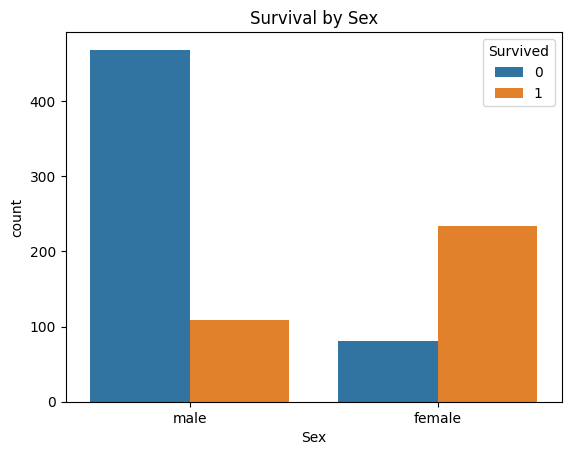

In [47]:
#compare servived & dead  male & female
sns.countplot(data=df, x="Sex", hue="Survived")
plt.title("Survival by Sex")
plt.show()

In [46]:
#compare according passenger class
pd.crosstab(df["Pclass"], df["Survived"])

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


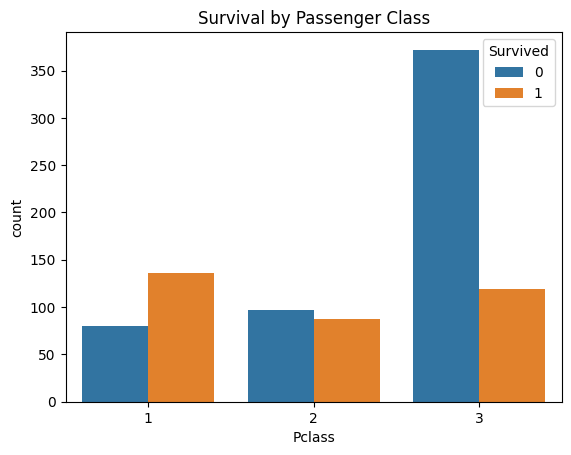

In [45]:
#compare according passenger class

sns.countplot(data=df, x="Pclass", hue="Survived")
plt.title("Survival by Passenger Class")
plt.show()

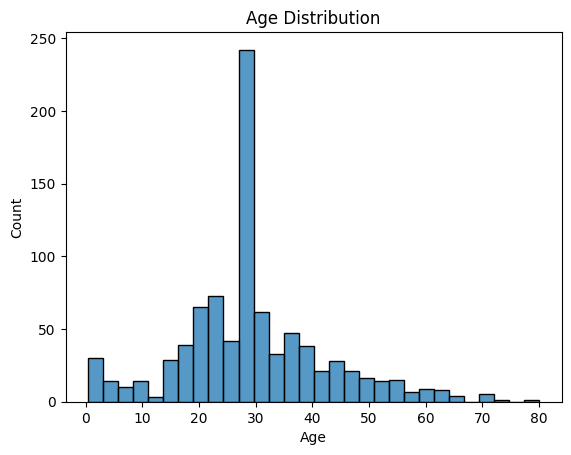

In [49]:
# accoring age & divided it in 30 division
sns.histplot(data=df, x="Age", bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

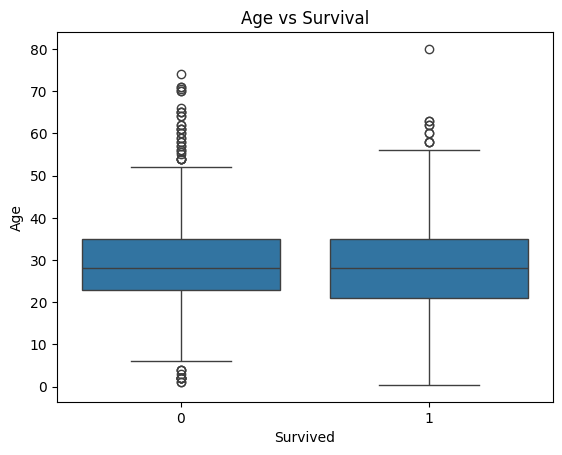

In [50]:
# survived vs age
sns.boxplot(data=df, x="Survived", y="Age")
plt.title("Age vs Survival")
plt.show()

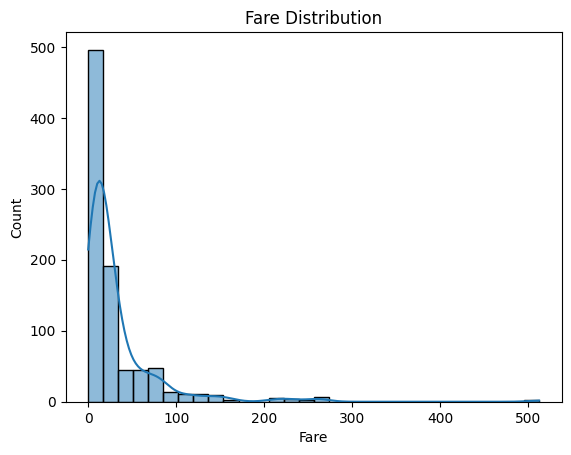

In [51]:
#divided in 30 part of Fare
sns.histplot(data=df, x="Fare", bins=30, kde=True)
plt.title("Fare Distribution")
plt.show()

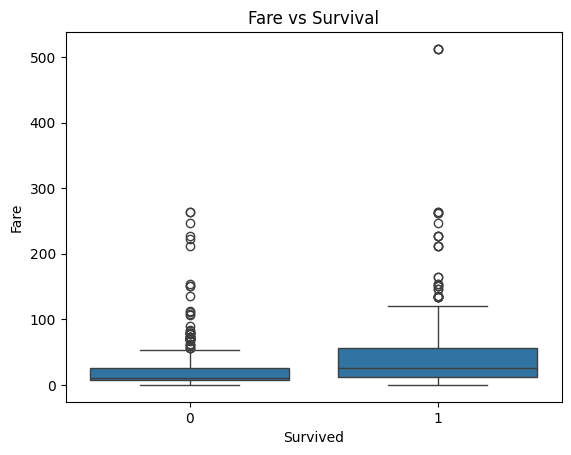

In [52]:

sns.boxplot(data=df, x="Survived", y="Fare")
plt.title("Fare vs Survival")
plt.show()

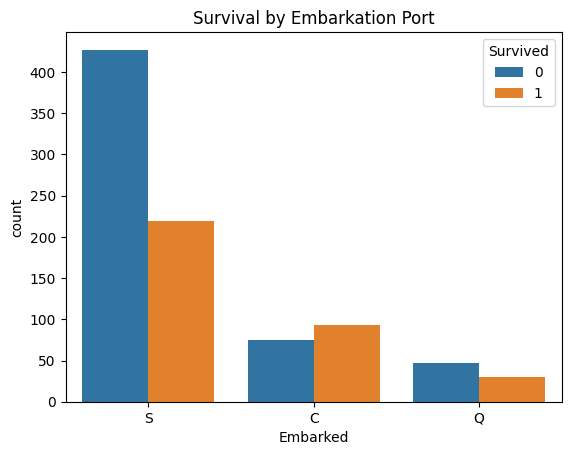

In [53]:
#survived wise Embarked
sns.countplot(data=df, x="Embarked", hue="Survived")
plt.title("Survival by Embarkation Port")
plt.show()

In [54]:
#number of siblings & number of parents
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

df.groupby("FamilySize")["Survived"].mean()

,Survived
FamilySize,
1,0.303538
2,0.552795
3,0.578431
4,0.724138
5,0.200000
6,0.136364
7,0.333333
8,0.000000
11,0.000000


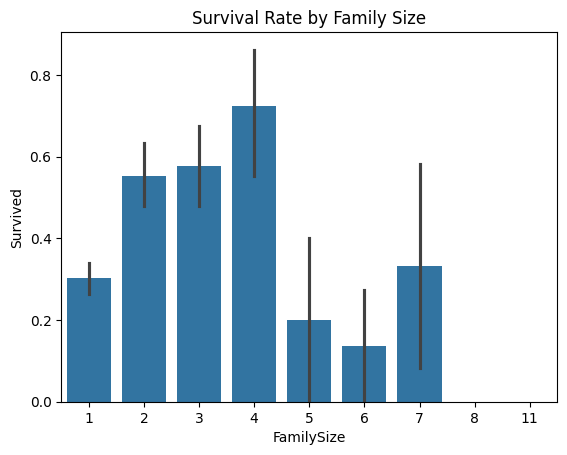

In [55]:
sns.barplot(data=df, x="FamilySize", y="Survived")
plt.title("Survival Rate by Family Size")
plt.show()

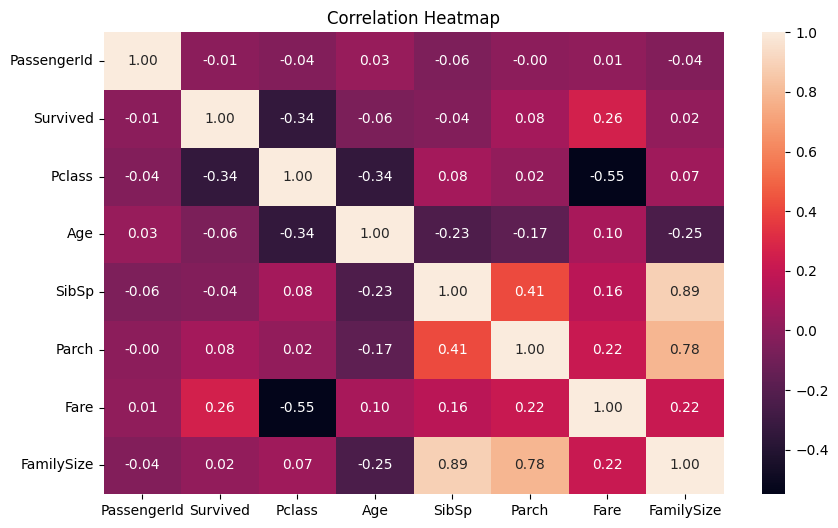

In [56]:
#take all numerical values data & show them according there intensity
plt.figure(figsize=(10, 6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

# Conclusion

After exploring the Titanic dataset, I found that survival was strongly related to some passenger characteristics.

- Female passengers had a much higher survival rate than male passengers.
- First-class passengers had better survival chances than passengers in lower classes.
- Age also showed some differences between survivors and non-survivors.
- Passengers who paid higher fares generally had better survival rates.
- Survival also varied depending on the embarkation port.
- Family size had some effect on survival as well.

I also handled the missing values in the Age and Embarked columns and removed the Cabin column because it contained too many missing values.